# giwaxs toolbox examples

Below are some example cells on how to use the plotting functions available in the giwaxs toolbox.

## Some tips on using jupyter notebooks:

- shift+enter  to run a cell
- ESC while jump out of the activate cell allowing the following commands:
   - shift+a  - gives a new cell above
   - m  - changes from code to markdown
   - y changes from markdown to code

In [ ]:
# typing text here after a hash appears as comment when code or title when markdown 

# 1. Using interactive widget to explore folder 

## Description
This option allows you to create a dropdown menu to select the filetype, and then a second dropdown menu with all files which have a filename containing the that filetype. The interactive folder explorer is started by using the following commands:

```python
from giwaxs_toolbox.plotting import individual_plotter
%matplotlib ipympl
ind=individual_plotter(datafolder='path/to/your/data')
```


Datasets saved using I07 fast_rsm software will be one of three types:

 - IvsQ :  this is a 1d dataset of an azimuthal integration with intensity data, along with 2theta and Q values

    
 - Qmap :  this is a 2d dataset of Intensity based on Q in-plane and Q out-of-plane


 - exitangles : this is a 2d dataset of Intensity based on exit angle perpendicular and exit angle parallel

If your dataset has higher indexes slider bars will show up allowing you to select which image from your dataset you want to view. 




## Code example

In [2]:
import sys
sys.executable
import giwaxs_toolbox

interactive(children=(Dropdown(description='scantype', options=('IvsQ', 'IvsChi', 'Qmap', 'exitmap', 'Chimap')…

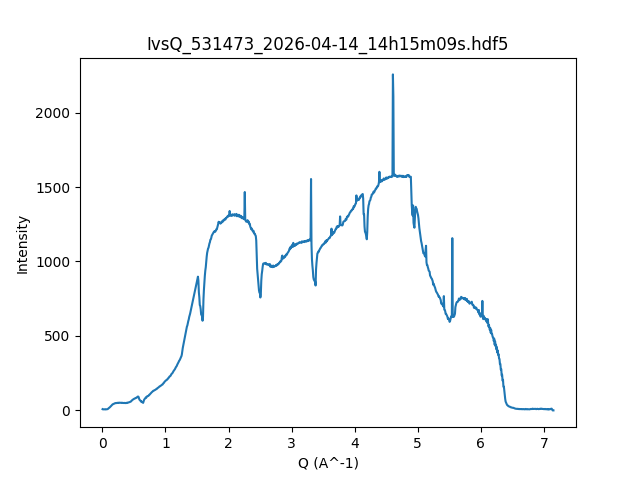

In [3]:
from giwaxs_toolbox.plotting import individual_plotter, reset_plots
#set interactive ipympl
%matplotlib ipympl

#create the plotter for individual datasets
folder1="/dls/science/groups/das/ExampleData/i07/fast_rsm_example_data/tests_versioned/v2.4.1_i07_2026-04-14"
ind=individual_plotter(datafolder=folder1)

# some useful tips when viewing interactive plots

- hovering the mouse over the current plot area shows a readout of the x,y,intensity values below the plot
- for 2d images the contrast can be adjusted by selecting the crossed arrows from the toolbar on the left, and then clicking and dragging on the colour bar

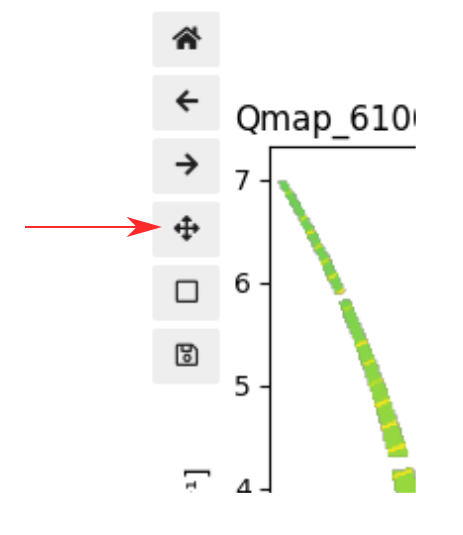
  - right-click and drag : increases or decreases the overall range of the colourmap
  - left-click and drag : moves the upper and lower limits together  


# interactivity issues

occassionally if you use multiple interactive plots at the same time matplotlib will stop plotting correctly. 
The function reset_plots() can be ran, which should hopefully reset matplotlib and allow plotting properly again. 
Below is an example of importing and using the reset_plots function  - running this cell and waiting 10 seconds usually enables the interactive plots

In [ ]:
from giwaxs_toolbox.plotting import reset_plots
reset_plots()

# 2. Quick comparison plotting

## Description
The giwaxs_toolbox has options for quick comparison plots, where given a list of files the plotter can create plots for quick comparisons

The first step is to create a comparison plotter using the commands, where the plotter can take anyname:

```python
    %matplotlib ipympl 
    plotter=comparison_plotter(datafolder='path/to/your/data')
```

Once you have the plotter object, you can then pass it a list of files and it will plot them for comparison. Note that all files must be of the same type. 

first define youfiles

```python
    filelist=['file1.hdf5','file2.hdf5']
```

if there is a single datset within each file, then you can simply enter the filenames and whether you want log scaling. 
    
```python
    combo_plotter.plot_files(filelist,logscale=True)
```

however if you files contain multiple datasets, you need to include a list of the indexes of the dataset you want to plot. For comparing files with multiple datasets to files with a single dataset, the index values shoudl be set to 0 for the file with a single dataset. Note that both index1 values and index2 values must be the same length as the filelist. 


```python
    # here file 1 is a single dataset so its indexes are 0
    # file 2 is (m x n x datashape) - selection is m=8 n=2
    ind1vals=np.array([0,8])  
    ind2vals=np.array([0,2])
    combo_plotter.plot_files(filelist,logscale=True)
```



- 

## Code example


In [ ]:
from giwaxs_toolbox.plotting import comparison_plotter, reset_plots
import numpy as np
#set interactive ipympl
%matplotlib ipympl

folder1='/dls/i07/data/2026/si44580-1/processing'


#load the comparison plotter
combo_plotter=comparison_plotter(datafolder=folder1)


## Example 1 -  comparing files which all have one dataset

In [ ]:
%matplotlib ipympl
reset_plots()
example_ivqfiles=['IvsQ_432196_2026-03-24_10h16m29s.hdf5','IvsQ_610009_2026-03-24_10h23m11s.hdf5']

example_qmapfiles=['Qmap_432196_2026-03-24_10h16m31s.hdf5','Qmap_610009_2026-03-24_10h23m02s.hdf5']
combo_plotter.plot_files(example_ivqfiles,logscale=True)

## Example 2 - comparing files which contain multiple datasets

In [ ]:
#filenames=['IvsQ_610009_2026-03-24_13h44m56s.hdf5','IvsQ_531473_2026-03-24_13h40m31s.hdf5']
%matplotlib ipympl
reset_plots()
filenames=['IvsQ_536350_2026-03-24_10h21m22s.hdf5' ,'IvsQ_531473_2026-03-24_10h17m25s.hdf5']
repeated_file=['IvsQ_531473_2026-03-24_10h17m25s.hdf5']*5
#,'Qmap_531473_2026-03-24_13h41m47s.hdf5' ,'Qmap_610009_2026-03-24_13h44m47s.hdf5','Qmap_531473_2026-03-24_13h41m47s.hdf5' ]
ind1vals=np.array([0,2,4,6,8])
ind2vals=np.array([0,0,0,0,0,0,0])
combo_plotter.plot_files(repeated_file,ind1vals,ind2vals,logscale=False)

# Extracting datasets to do specialised plots

## Description
giwaxs_toolbox also has functions to extract the 1d or 2d datasets from i07 processed files which can then be used in personalised plots

first create a data loader using the following syntax:

```python
from giwaxs_toolbox.processing import data_loader
loader =  data_loader(datafolder='path/to/your/data')
```

Once you have a data loader for your data folder you can extract a series of datasets using the syntax:

```python
filelist=['file1','file2','file3']
results= loader.loadfiles(filelist)
```

This will then give you a list of your datasets, each of which will either be of the type result1d or result2d. These result objects have the following attributes:

result1d

```python
result1d.data  # the one dimensional profile data
result1d.x_axis # the axis data for the x-axis
```

result2d

```python
result2d.data   # the two dimensional image data
result2d.x_axis # the axis data for the x-axis
result2d.y_axis # the axis data for the y-axis
```



## loading in 1d datasets

In [ ]:
from giwaxs_toolbox.processing import data_loader
from giwaxs_toolbox.plotting import reset_plots
import matplotlib.pyplot as plt
from pprint import pprint
import numpy as np

In [ ]:
folder1="/dls/science/groups/das/ExampleData/i07/fast_rsm_example_data/tests_versioned/v2.4.1_i07_2026-04-14"
filelist= [file for file in os.listdir(folder1) if file.endswith('.hdf5')]

#create your data loader for your data directory path
loader=data_loader(datafolder=folder1)

#choose which datasets you want to load
example_ivqfiles=["IvsQ_536350_2026-04-14_14h20m34s.hdf5"]*10#, "IvsQ_610009_2026-02-18_16h55m51s.hdf5"]

# load the files into a results object
ivqresults=loader.loadfiles(example_ivqfiles,index1vals= np.arange(0,100,10))

In [ ]:

from pathlib import Path
import h5py
import numpy as np
def read_1dbatch_datafile(
    self, filepath: Path, paths: list, index1: np.int32, index2: np.int32
):
    with h5py.File(filepath) as h5data:
        y_shape = np.shape(h5data[paths[0]])
        x_shape = np.shape(h5data[paths[1]])
        expected_shape = np.int32(1)
        dataind, index1, index2, indmax2, indmax1 = self.check_shape(
            y_shape, expected_shape, index1, index2
        )
        axisind, *_ = self.check_shape(x_shape, expected_shape, index1, index2)
        result = self.get_1d_data(h5data, paths, dataind, axisind)
    return result, index1, index2, indmax1, indmax2

In [ ]:
h5data = h5py.File(Path(folder1) / "IvsQ_531473_2026-04-14_14h15m09s.hdf5")


In [ ]:
int_path = "integrations/Intensity"
q_path = "integrations/Q_angstrom^-1"
paths = [int_path, q_path]
y_shape = np.shape(h5data[paths[0]])
x_shape = np.shape(h5data[paths[1]])
expected_shape = np.int32(1)


In [ ]:
valind=(slice(None),5,slice(None))
np.shape(h5data[int_path][valind])

In [ ]:
h5data[q_path]

In [ ]:
#set interactive ipympl
%matplotlib ipympl

#create your figure
fig,axs=plt.subplots(figsize=(10,4))

#use the result objects from the results list to plot onto the graph
for num,res in enumerate(ivqresults):
    axs.semilogy(res.x_axis,res.data,label=example_ivqfiles[num])

axs.axvline(2,ls='--')
axs.axvline(6,ls='--',color='red')
plt.legend()
plt.show

## loading in 2d datasets
You can do the same process for 2d datasets as well, below is an example using the result2d objects along with extra plotting shapes for customised plots

In [ ]:

import matplotlib.pyplot as plt
from matplotlib.patches import Annulus, Wedge

folder1='/dls/i07/data/2026/si44580-1/processing'

#create your data loader for your data directory path, note if the 2d datasets are in the same folder as the 1d datasets the loader from the previous section can be reused
loader=data_loader(datafolder=folder1)


#choose which datasets you want to load
exitmap_filenames=['exitmap_610009_2026-03-24_10h23m19s.hdf5','exitmap_432196_2026-03-24_10h16m26s.hdf5']

# load the files into a results object
exitmapresults=loader.loadfiles(exitmap_filenames)



In [ ]:
print(exitmapresults[1])

In [ ]:
fig,axs=plt.subplots(1,2,figsize=(10,4))

axlist=axs.flatten()
for i,res in enumerate(exitmapresults):
    maplimits=[res.x_axis.min(), res.x_axis.max(), res.y_axis.min(),res.y_axis.max()]
    map2d=res.data
    axlist[i].imshow(map2d,vmax=map2d.mean()+2*map2d.std(),extent=maplimits,alpha=0.95)
    #axlist[i].set_aspect('equal')
    axlist[i].set_xlabel('exit_para (deg)')
    axlist[i].set_ylabel('exit_perp (deg)')

selection_ring=Annulus((0,0), 15, 1.25,color='red',alpha=0.55)
selection_wedge = Wedge((0.0),40,40,60,color='red',alpha=0.5)
axlist[0].add_patch(selection_ring)
axlist[1].add_patch(selection_wedge)
plt.tight_layout()
plt.show()

# 4. Quick peak fitting

This cell below is if you have already loaded in some 1d data, and can then select specific peaks to carry out a peak fitting routine on. 
First create a set of peaks you want to use in the fit following the format

```python
peak1 = {'type':name-of-peak,
         'settings':
            {'center':[6.25,6.2,6.3],
             'sigma': [0.02,1e-6,0.1],
             'amplitude': [7,1e-6,18],
             'fraction':[0.15,0,1]}
         }
```

The currently supported peak type names are listed below, and use [built-in models](https://lmfit.github.io/lmfit-py/builtin_models.html) within the lmfit python package - click on the links below to find out more about the available settings for each peak type

- ``` "pvoigt"```: fits using [PseudoVoigtModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.PseudoVoigtModel),
- ``` "gaussian"```: fits using [GaussianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.GaussianModel),
- ``` "lorentzian"```: fits using  [LorentzianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.LorentzianModel),
- ``` "split_lorentzian"```: fits using  [SplitLorentzianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.SplitLorentzianModel),
- ``` "skewed_gaussian"```: fits using  [SkewedGaussianModel](https://lmfit.github.io/lmfit-py/builtin_models.html#lmfit.models.SkewedGaussianModel),
 

In [ ]:
from giwaxs_toolbox.processing import peakfit_and_plot


peak1 = {'type':'pvoigt',
         'settings':
            {'center':[0.4,0.35,0.425],
             'sigma': [0.02,1e-6,0.05],
             'amplitude': [7,1e-6,18000],
             'fraction':[0.15,0,1]}
         }

peak2 = {'type':'pvoigt',
         'settings':
            {'center':[0.43,0.42,0.5],
             'sigma': [0.02,1e-6,0.1],
             'amplitude': [7,1e-6,1800],
             'fraction':[0.15,0,1]}
         }
#peaklist=[peak1]       
peaklist=[peak2]
result_list=[]

for i in np.arange(5):
    res=ivqresults[i]
    q=res.x_axis
    intensity=res.data
    con1=q>0.43
    con2=q<0.55
    selection=con1&con2
    x=q[selection]
    y=intensity[selection]
    report=peakfit_and_plot(peaklist,x,y)
    result_list.append(report)





In [ ]:
p1fwvals = [result.params['p1_fwhm'].value for result in result_list]
#p2fwvals = [result.params['p2_fwhm'].value for result in result_list]

In [ ]:
fig,ax = plt.subplots(1,1)
plt.plot(p1fwvals, marker='o')
